# YOLOv11n Baseline — pilliot_15k_optimized_leakage_free_split

- 모델: YOLOv11n (COCO pretrained)
- 데이터: pilliot_15k_optimized_leakage_free_split (single 12k + combination 3k, 1-class: pill)
- 하이퍼파라미터: AdamW lr=0.002, 30 epochs, 640px, bs=16

In [3]:
!pip install ultralytics -q

from google.colab import drive
import os, shutil, zipfile, yaml, random
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

## 1. Drive 마운트 및 경로 설정

In [4]:
drive.mount('/content/drive')

PILLOT_ROOT = '/content/drive/MyDrive/Conference/Pill-agent/Pillot'
DATASET_DIR = f'{PILLOT_ROOT}/dataset'
ZIP_PATH    = f'{DATASET_DIR}/pilliot_15k_optimized_leakage_free_split.zip'

assert 'pilliot_15k_optimized_leakage_free_split.zip' in os.listdir(DATASET_DIR), \
    f'zip 없음. dataset/ 목록: {os.listdir(DATASET_DIR)}'
print(f'경로 확인 완료: {PILLOT_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
경로 확인 완료: /content/drive/MyDrive/Conference/Pill-agent/Pillot


## 2. Manifest 로드 및 스키마 확인

In [5]:
import io as _io, zipfile as _zf

print('manifests 로딩 중 (zip 직접 접근)...')
with _zf.ZipFile(ZIP_PATH) as bz:
    names = bz.namelist()
    bbox_train_name = next((f for f in names if 'bbox_manifest_train' in f), None)
    bbox_val_name   = next((f for f in names if 'bbox_manifest_val'   in f), None)
    if not bbox_train_name:
        print('[진단] zip 내 csv 목록:')
        for n in [x for x in names if x.endswith('.csv')]:
            print(f'  {n}')
        raise FileNotFoundError('bbox_manifest_train 파일을 찾을 수 없습니다.')
    print(f'train: {bbox_train_name}')
    print(f'val:   {bbox_val_name}')
    train_df = pd.read_csv(_io.BytesIO(bz.read(bbox_train_name)), low_memory=False)
    val_df   = pd.read_csv(_io.BytesIO(bz.read(bbox_val_name)),   low_memory=False)

required = {'image_file', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h'}
assert not (required - set(train_df.columns)), f'컬럼 누락: {required - set(train_df.columns)}'

print(f'\ntrain: {len(train_df):,}행, {train_df["image_file"].nunique():,}개 이미지')
print(f'val:   {len(val_df):,}행, {val_df["image_file"].nunique():,}개 이미지')
print(f'\n컬럼: {train_df.columns.tolist()}')

manifests 로딩 중 (zip 직접 접근)...
train: pilliot_15k_optimized_leakage_free_split/manifests/bbox_manifest_train_with_attributes.csv
val:   pilliot_15k_optimized_leakage_free_split/manifests/bbox_manifest_val_with_attributes.csv

train: 19,733행, 12,252개 이미지
val:   3,784행, 2,748개 이미지

컬럼: ['sample_pack', 'sample_part', 'detection_source', 'dataset_type', 'split_type', 'label_zip_name', 'image_zip_name', 'image_gcs_zip', 'json_file', 'image_file', 'dl_mapping_code', 'item_seq', 'dl_name', 'drug_shape', 'color_class1', 'color_class2', 'form_code_name', 'print_front', 'print_back', 'line_front', 'line_back', 'shape_group', 'color_group', 'line_binary', 'has_print', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'area', 'yolo_class_id', 'yolo_class_name', 'dl_company', 'local_image_path', 'relative_image_path', 'image_exists', 'component_id', 'split', 'pack_relative_image_path', 'pack_name']


## 3. zip 압축 해제

In [6]:
for _p in ['/content/raw', '/content/pilliot_15k_opt.zip',
           '/content/images', '/content/labels', '/content/runs']:
    _pp = Path(_p)
    if _pp.exists():
        shutil.rmtree(_p, ignore_errors=True) if _pp.is_dir() else os.remove(_p)

print('zip을 /content/로 복사 중...')
shutil.copy(ZIP_PATH, '/content/pilliot_15k_opt.zip')

print('압축 해제 중...')
with zipfile.ZipFile('/content/pilliot_15k_opt.zip') as zf:
    zf.extractall('/content/raw/')
os.remove('/content/pilliot_15k_opt.zip')

raw_root = Path('/content/raw')
subdirs  = [d for d in raw_root.iterdir() if d.is_dir()]
EXTRACT_ROOT = subdirs[0] if len(subdirs) == 1 and not (raw_root / 'images').exists() else raw_root
print(f'추출 루트: {EXTRACT_ROOT}')

all_imgs = list((EXTRACT_ROOT / 'images').rglob('*.png')) + \
           list((EXTRACT_ROOT / 'images').rglob('*.jpg'))
img_lookup = {p.name: p for p in all_imgs}
print(f'총 이미지 수: {len(img_lookup):,}')
for split in ['train', 'val']:
    cnt = len(list((EXTRACT_ROOT / 'images' / split).iterdir()))
    print(f'  {split}: {cnt:,}')

zip을 /content/로 복사 중...
압축 해제 중...
추출 루트: /content/raw/pilliot_15k_optimized_leakage_free_split
총 이미지 수: 15,000
  train: 2
  val: 2


## 4. Train / Val 분할 및 이미지 구성

In [7]:
shutil.rmtree('/content/images', ignore_errors=True)

for split in ['train', 'val']:
    src_dir = EXTRACT_ROOT / 'images' / split
    dst_dir = Path(f'/content/images/{split}')
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img_path in list(src_dir.rglob('*.png')) + list(src_dir.rglob('*.jpg')):
        dst = dst_dir / img_path.name
        if not dst.exists():
            os.symlink(img_path.resolve(), dst)
    print(f'{split}: {len(list(dst_dir.iterdir())):,} 이미지')

train: 12,252 이미지
val: 2,748 이미지


## 5. YOLO 라벨 변환
COCO `[x, y, w, h]` (픽셀) → YOLO `[xc, yc, w, h]` (정규화)

In [8]:
from PIL import Image as _PIL

_dim_cache = {}

def _get_dims(fname):
    if fname not in _dim_cache:
        src = img_lookup.get(fname)
        if src is None:
            _dim_cache[fname] = None
        else:
            with _PIL.open(src) as im:
                _dim_cache[fname] = im.size  # (w, h)
    return _dim_cache[fname]

def coco_to_yolo(row):
    bx, by, bw, bh = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
    if pd.isna(bx) or bw < 1 or bh < 1:
        return None
    if 'width' in row.index and not pd.isna(row.get('width')):
        iw, ih = row['width'], row['height']
    else:
        dims = _get_dims(row['image_file'])
        if dims is None:
            return None
        iw, ih = dims
    xc = (bx + bw / 2) / iw
    yc = (by + bh / 2) / ih
    return f'0 {xc:.6f} {yc:.6f} {bw/iw:.6f} {bh/ih:.6f}'

def write_labels(subset_df, split):
    label_dir = Path(f'/content/labels/{split}')
    label_dir.mkdir(parents=True, exist_ok=True)
    skipped = 0
    for fname, grp in subset_df.groupby('image_file'):
        lines = []
        for _, row in grp.iterrows():
            line = coco_to_yolo(row)
            if line:
                lines.append(line)
            else:
                skipped += 1
        if lines:
            (label_dir / (Path(fname).stem + '.txt')).write_text('\n'.join(lines))
    n = len(list(label_dir.glob('*.txt')))
    print(f'{split}: {n:,} 라벨 파일 생성, {skipped} annotation 스킵')

shutil.rmtree('/content/labels', ignore_errors=True)
write_labels(train_df, 'train')
write_labels(val_df,   'val')

train: 12,252 라벨 파일 생성, 0 annotation 스킵
val: 2,748 라벨 파일 생성, 0 annotation 스킵


## 6. 이미지-라벨 매칭 검증

In [9]:
def validate_pairs(split):
    imgs   = {p.stem for p in Path(f'/content/images/{split}').iterdir()
              if p.suffix in {'.jpg', '.png'}}
    labels = {p.stem for p in Path(f'/content/labels/{split}').glob('*.txt')}
    no_label = imgs - labels
    no_image = labels - imgs
    print(f'[{split}] images: {len(imgs):,}, labels: {len(labels):,}')
    print(f'  라벨 없는 이미지: {len(no_label)}')
    print(f'  이미지 없는 라벨: {len(no_image)}')

validate_pairs('train')
validate_pairs('val')

[train] images: 12,252, labels: 12,252
  라벨 없는 이미지: 0
  이미지 없는 라벨: 0
[val] images: 2,748, labels: 2,748
  라벨 없는 이미지: 0
  이미지 없는 라벨: 0


## 7. dataset.yaml 생성

In [10]:
cfg = {
    'path':  '/content',
    'train': 'images/train',
    'val':   'images/val',
    'nc':    1,
    'names': ['pill'],
}
with open('/content/dataset.yaml', 'w') as f:
    yaml.dump(cfg, f, allow_unicode=True)
print(open('/content/dataset.yaml').read())

names:
- pill
nc: 1
path: /content
train: images/train
val: images/val



## 8. 학습

In [11]:
model = YOLO('yolo11n.pt')
results = model.train(
    data='/content/dataset.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.002,
    patience=5,
    device=0,
    project='/content/runs',
    name='yolo11n_15k_baseline',
)

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_15k_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patienc

KeyboardInterrupt: 

## 9. 검증

In [12]:
metrics = model.val()
print(f'mAP50:     {metrics.box.map50:.4f}')
print(f'mAP50-95:  {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall:    {metrics.box.mr:.4f}')

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 12,675 gradients, 6.3 GFLOPs


FileNotFoundError: '/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml' does not exist

## 10. 결과 Drive 저장

In [13]:
dst = f'{PILLOT_ROOT}/runs/yolo11n_15k_baseline'
shutil.copytree(
    '/content/runs/yolo11n_15k_baseline',
    dst,
    dirs_exist_ok=True
)
print(f'저장 완료: {dst}')

저장 완료: /content/drive/MyDrive/Conference/Pill-agent/Pillot/runs/yolo11n_15k_baseline


## 11. Augmentation Stress Test 함수 정의
- `aug_finger`: 피부색 직사각형 2~4개로 손가락 가리기
- `aug_overlap`: pill crop 복사 → 기존 bbox 위에 오프셋 붙이기
- `aug_half_crop`: 상/하/좌/우 절반 크롭

In [14]:
def aug_finger(img):
    out = img.copy()
    h, w = out.shape[:2]
    for _ in range(random.randint(2, 4)):
        skin = (random.randint(60, 130), random.randint(90, 160), random.randint(140, 220))
        fw = random.randint(w // 12, w // 7)
        fh = random.randint(int(h * 0.35), int(h * 0.65))
        fx, fy = random.randint(0, w - fw), random.randint(0, h - fh)
        cv2.rectangle(out, (fx, fy), (fx + fw, fy + fh), skin, -1)
        out[fy:fy+fh, fx:fx+fw] = cv2.GaussianBlur(out[fy:fy+fh, fx:fx+fw], (11, 11), 4)
    return out

def aug_overlap(img, label_path):
    out = img.copy()
    h, w = out.shape[:2]
    lp = Path(label_path)
    if not lp.exists():
        return out
    lines = [l for l in lp.read_text().strip().split('\n') if l]
    if not lines:
        return out
    _, xc, yc, bw, bh = map(float, random.choice(lines).split())
    x1 = max(0, int((xc - bw / 2) * w))
    y1 = max(0, int((yc - bh / 2) * h))
    x2 = min(w, int((xc + bw / 2) * w))
    y2 = min(h, int((yc + bh / 2) * h))
    crop = out[y1:y2, x1:x2].copy()
    cw, ch = x2 - x1, y2 - y1
    if cw < 5 or ch < 5:
        return out
    nx = min(w - cw, max(0, x1 + cw // 3))
    ny = min(h - ch, max(0, y1 + random.randint(-ch // 4, ch // 4)))
    out[ny:ny+ch, nx:nx+cw] = crop
    return out

def aug_half_crop(img):
    h, w = img.shape[:2]
    d = random.choice(['left', 'right', 'top', 'bottom'])
    return {'left': img[:, :w//2], 'right': img[:, w//2:],
            'top':  img[:h//2, :], 'bottom': img[h//2:, :]}[d]


## 12. Stress Test 시각화
6샘플 × 4조건(original / finger / overlap / half_crop) 그리드. 각 셀 제목에 검출 수 표시.

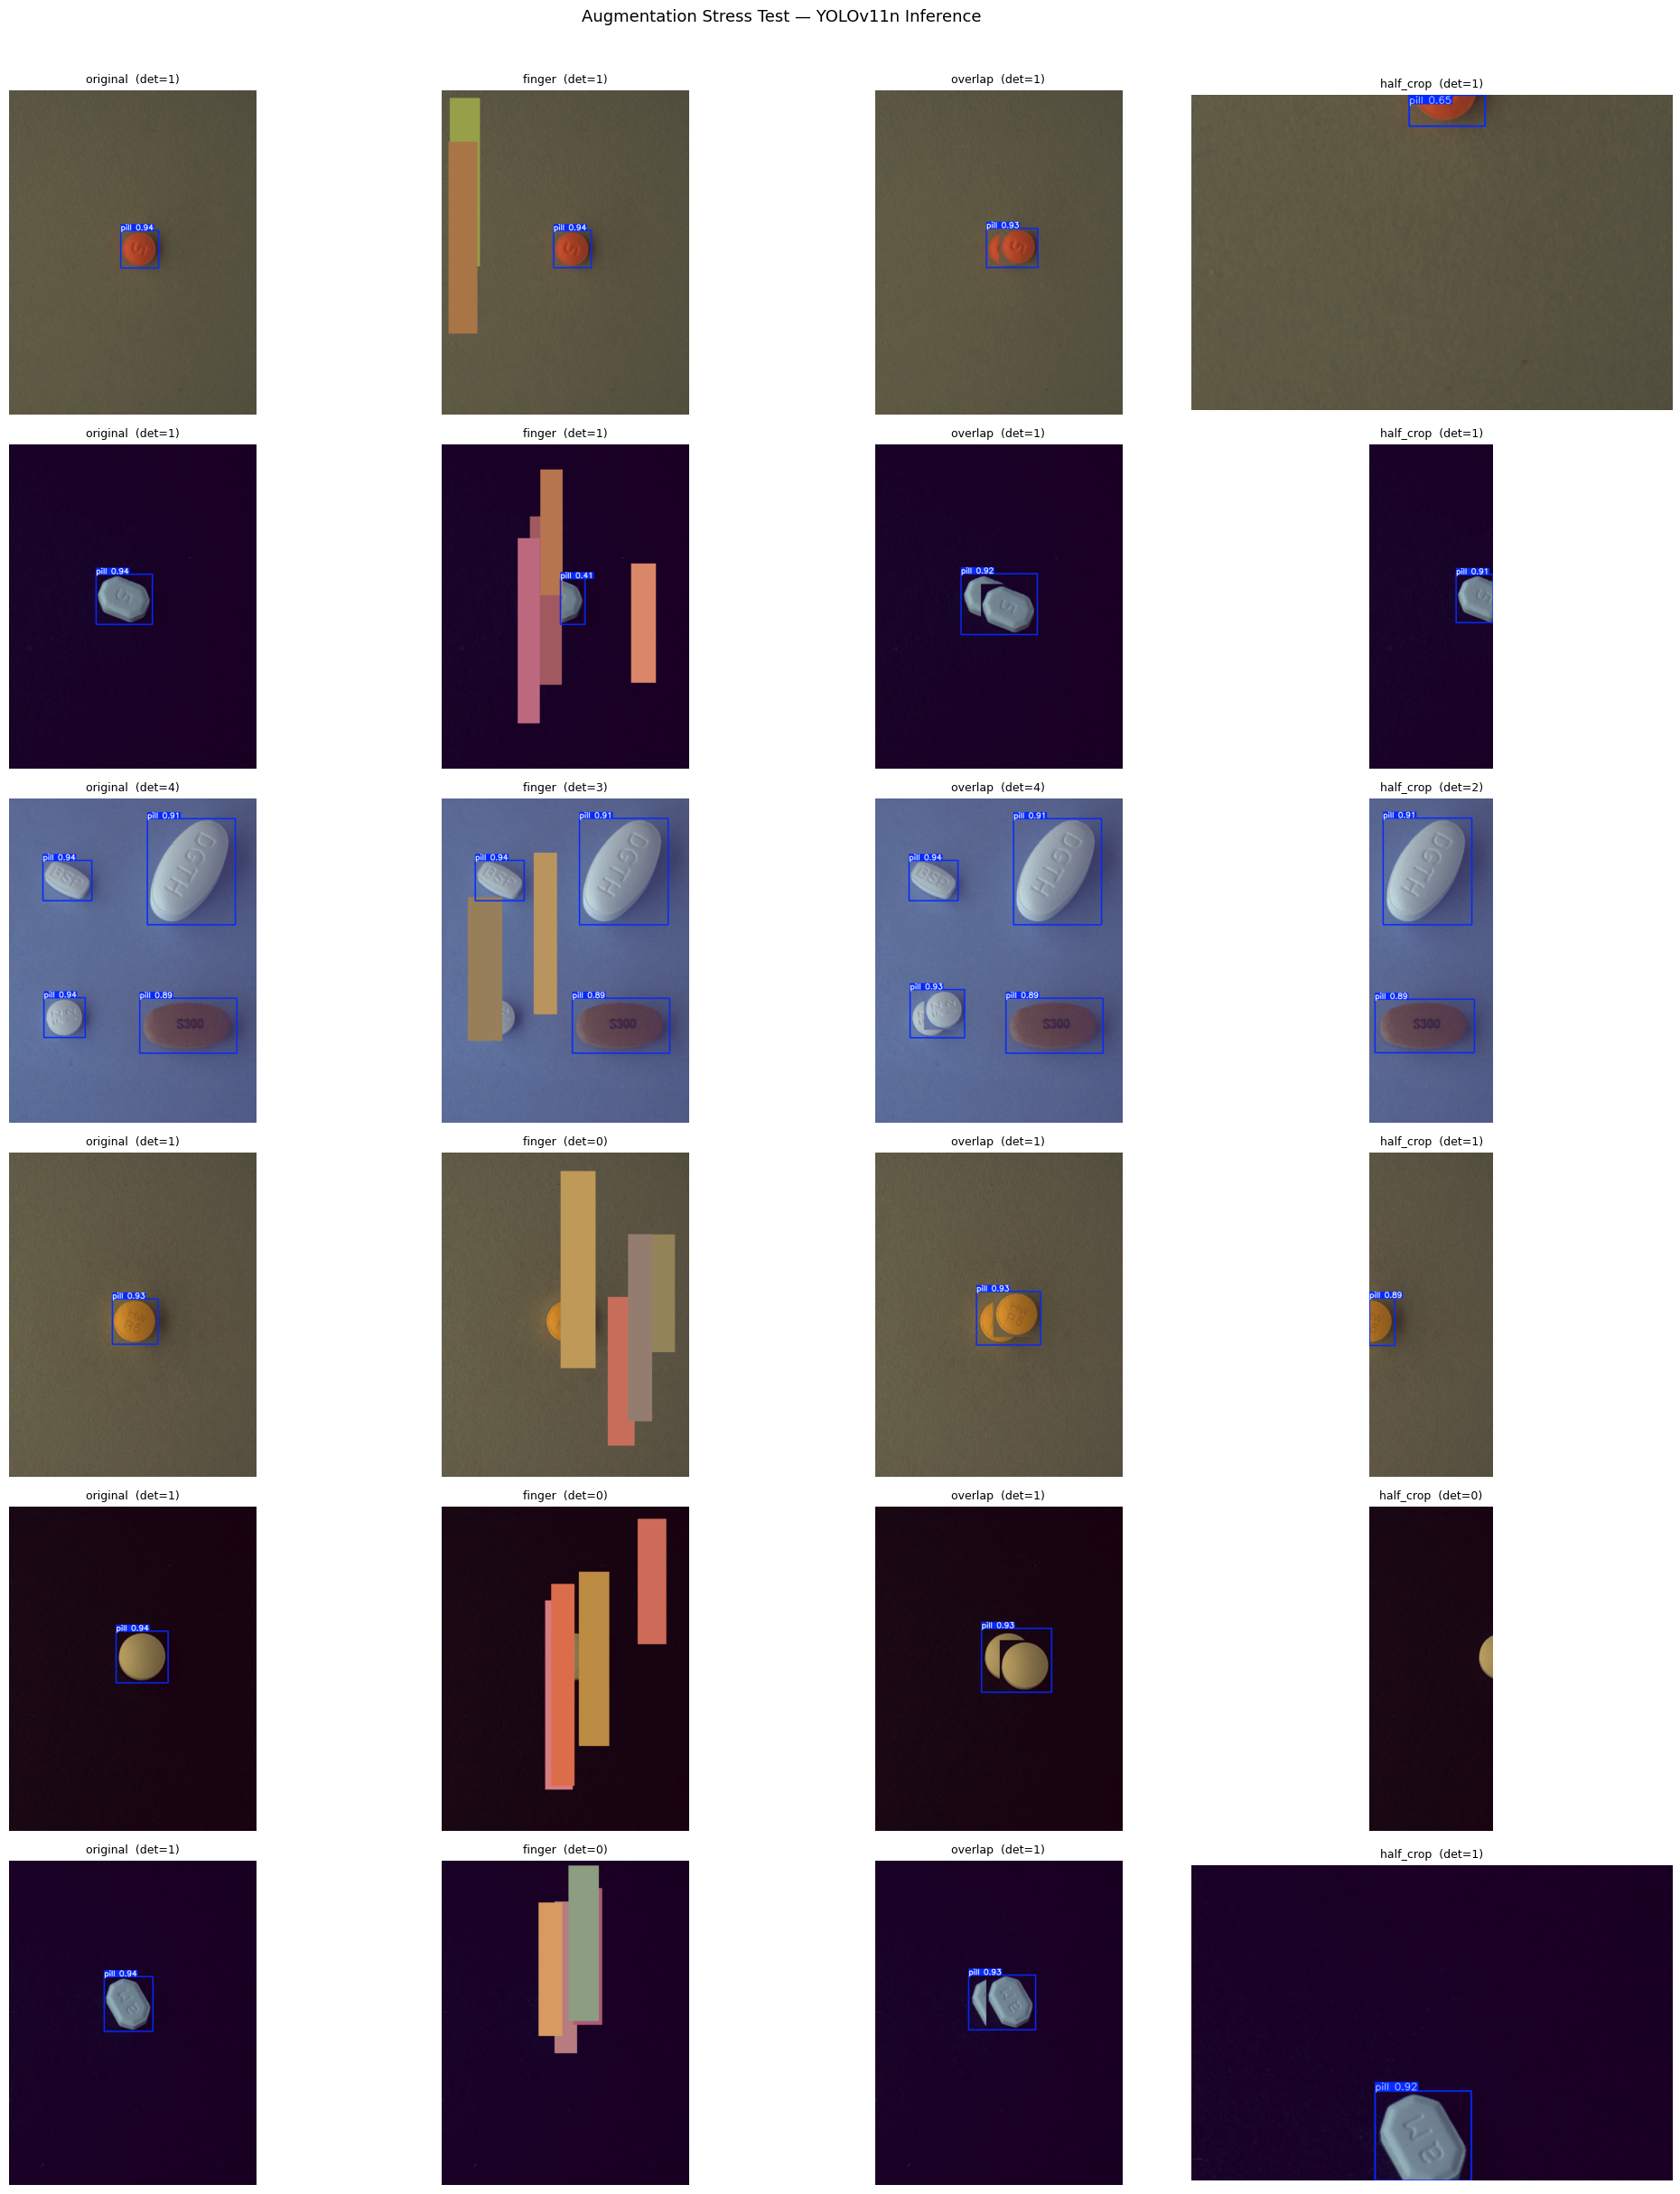

In [15]:
best_pt = '/content/runs/yolo11n_15k_baseline/weights/best.pt'
if not Path(best_pt).exists():
    best_pt = f'{PILLOT_ROOT}/runs/yolo11n_15k_baseline/weights/best.pt'
model = YOLO(best_pt)

random.seed(42)
val_imgs = random.sample(list(Path('/content/images/val').iterdir()), 6)
aug_fns = {
    'original':  lambda img, lp: img,
    'finger':    lambda img, lp: aug_finger(img),
    'overlap':   lambda img, lp: aug_overlap(img, lp),
    'half_crop': lambda img, lp: aug_half_crop(img),
}

fig, axes = plt.subplots(len(val_imgs), len(aug_fns), figsize=(20, 4 * len(val_imgs)))
fig.suptitle('Augmentation Stress Test — YOLOv11n Inference', fontsize=13, y=1.01)

for r, img_path in enumerate(val_imgs):
    lp = str(Path('/content/labels/val') / (img_path.stem + '.txt'))
    img_bgr = cv2.imread(str(img_path))
    for c, (name, fn) in enumerate(aug_fns.items()):
        aug = fn(img_bgr.copy(), lp)
        res = model.predict(aug, conf=0.25, verbose=False)[0]
        vis = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
        axes[r][c].imshow(vis)
        axes[r][c].set_title(f'{name}  (det={len(res.boxes)})', fontsize=9)
        axes[r][c].axis('off')

plt.tight_layout()
plt.savefig(f'{PILLOT_ROOT}/stress_test_vis.png', dpi=150, bbox_inches='tight')
plt.show()